In [578]:
import sys
sys.path.append(r"C:\Users\cigp4g\Downloads")  # ✅ Raw string avoids escape issues
import AMC

# basic move to particle and print SEM image and location

In [150]:
# ─── Drift check: move back to "Sample Top Left" ──────────────────────────────
corner_file = "LM_sample_stage_corners.csv"   # or fiducials_LM.csv
df_corners = pd.read_csv(corner_file)

# If using the corner CSV
origin = df_corners.loc[df_corners["Name"] == "Sample Top Left"].iloc[0]
x0_nm = int(origin["X"] * 1e9)  # convert m → nm if saved that way
y0_nm = int(origin["Y"] * 1e9)

print(f"\n📍 Returning to origin → Sample Top Left "
      f"X = {x0_nm} nm, Y = {y0_nm} nm")

# Move X
dev.move.setControlTargetPosition(0, x0_nm)
dev.control.setControlMove(0, True)
wait_for_ready_or_stop(dev, 0)

# Move Y
dev.move.setControlTargetPosition(1, y0_nm)
dev.control.setControlMove(1, True)
wait_for_ready_or_stop(dev, 1)

# Disable servos for safety
dev.control.setControlMove(0, False)
dev.control.setControlMove(1, False)

# Confirm final position
time.sleep(0.5)
x_cur = dev.move.getPosition(0)[1]
y_cur = dev.move.getPosition(1)[1]
print(f"→ Current stage pos: X = {x_cur:.0f} nm, Y = {y_cur:.0f} nm")
print(f"→ Drift relative to origin: ΔX = {x_cur - x0_nm:.0f} nm, ΔY = {y_cur - y0_nm:.0f} nm")



📍 Returning to origin → Sample Top Left X = -1867743 nm, Y = 240076 nm
→ Axis 0 is Ready (waited 0.34 s)
→ Axis 1 is In Target Range (waited 0.46 s)
→ Current stage pos: X = -1867748 nm, Y = 240061 nm
→ Drift relative to origin: ΔX = -5 nm, ΔY = -15 nm


🔬 Particle 1031 diameter → 1.50 µm

📍 Moving to particle 1031 → X = 1556506 nm, Y = -847148 nm

→ Axis 0 is Ready (waited 0.35 s)
→ Axis 1 is Ready (waited 0.24 s)
→ Now at X: 1556508 nm
→ Now at Y: -847146 nm


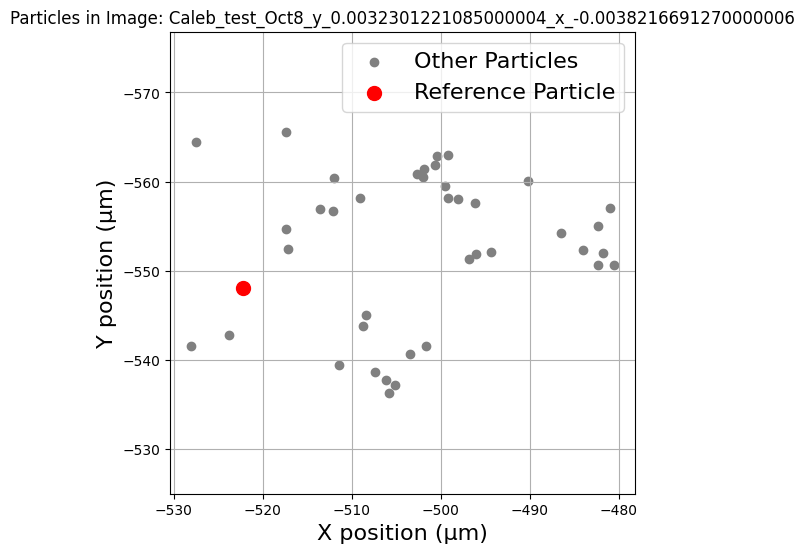

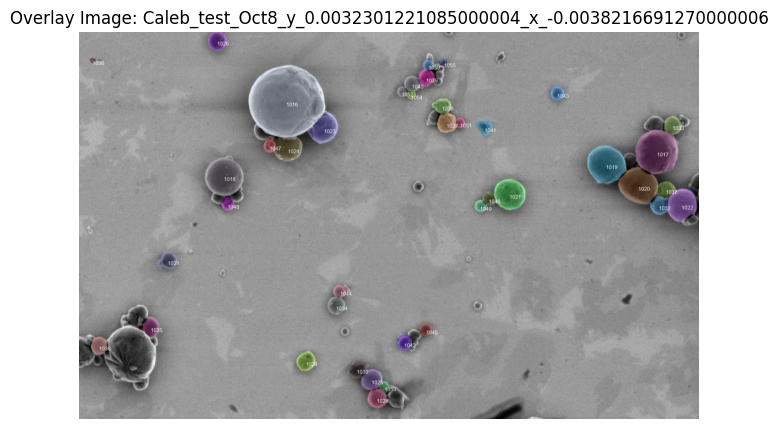

In [ ]:
import AMC
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# ─── Connect to AMC ───────────────────────────────────────────────────────────
dev = AMC.Device("#######")
dev.connect()

# Kill any lingering active moves at startup
dev.control.setControlMove(0, False)
dev.control.setControlMove(1, False)
time.sleep(0.2)

# ─── Load particle CSV ────────────────────────────────────────────────────────
df = pd.read_csv("particle_LM_stage_positions_plain_October8.csv")

# ─── Choose particle ────────────────────────────────────────────────────────
idx = 1031

row = df.loc[idx]
x_m = row["lm_stage_x_m"] #was lm_stage_x_m for some datasets
y_m = row["lm_stage_y_m"]

if "diameter_m" in row:
    diam_m = row["diameter_m"]
else:
    diam_m = (row["major_m"] * row["minor_m"])**0.5
diam_um = diam_m * 1e6
print(f"🔬 Particle {idx} diameter → {diam_um:.2f} µm\n")

x_nm = int(x_m * 1e9)
y_nm = int(y_m * 1e9)
print(f"📍 Moving to particle {idx} → X = {x_nm} nm, Y = {y_nm} nm\n")

# ─── Status functions ─────────────────────────────────────────────────────────
def get_axis_state(dev, axis: int) -> str:
    s = dev.Status(dev)
    _, in_target = s.getStatusTargetRange(axis)
    _, is_moving = s.getStatusMoving(axis)
    if is_moving:
        return "Moving"
    elif in_target:
        return "In Target Range"
    else:
        return "Ready"


READY_STATES = {"Ready", "In Target Range"}

def wait_for_ready_or_stop(dev, axis, timeout=2, poll_interval=0.1):
    """
    Wait until the axis is in 'Ready' or 'In Target Range', or until timeout.
    Returns True if ready/in-target, False on timeout.
    """
    t0 = time.time()
    while True:
        state = get_axis_state(dev, axis)
        if state in READY_STATES:  # ← this is the key change
            elapsed = time.time() - t0
            print(f"→ Axis {axis} is {state} (waited {elapsed:.2f} s)")
            return True
        if time.time() - t0 > timeout:
            print(f"⏳ Timeout ({timeout}s) on axis {axis}, last state={state}; disabling servo")
            try:
                dev.control.setControlMove(axis, False)
            except Exception:
                pass
            return False
        time.sleep(poll_interval)


# ─── Move stage safely ────────────────────────────────────────────────────────
dev.move.setControlTargetPosition(0, x_nm)
dev.control.setControlMove(0, True)
wait_for_ready_or_stop(dev, 0)     # now waits up to 2 s

dev.move.setControlTargetPosition(1, y_nm)
dev.control.setControlMove(1, True)
wait_for_ready_or_stop(dev, 1)     # ditto

# Optional: disable servo again after reaching position
dev.control.setControlMove(0, False)
dev.control.setControlMove(1, False)

# ─── Confirm position ─────────────────────────────────────────────────────────
time.sleep(0.5)
print("→ Now at X:", dev.move.getPosition(0)[1], "nm")
print("→ Now at Y:", dev.move.getPosition(1)[1], "nm")

# ─── Plot neighbors and overlay ───────────────────────────────────────────────
ref_image = row["ImageOrigin"]
df_same_image = df[df["ImageOrigin"] == ref_image]

plt.figure(figsize=(6, 6))
plt.scatter(df_same_image["sample_x_m"] * 1e6,
            df_same_image["sample_y_m"] * 1e6,
            c='gray', label="Other Particles")
plt.scatter(row["sample_x_m"] * 1e6,
            row["sample_y_m"] * 1e6,
            c='red', s=100, label="Reference Particle")
plt.xlabel("X position (µm)", fontsize=16)
plt.ylabel("Y position (µm)",fontsize=16)
plt.title(f"Particles in Image: {ref_image}")
plt.legend(fontsize=16)
plt.gca().invert_yaxis()
plt.axis('equal')
plt.grid(True)
plt.show()

overlay_dir = r"\\umad.umsystem.edu\RDE\maschmannm-lab\Caleb Oct8\overlays"
overlay_path = os.path.join(overlay_dir, f"{ref_image}_overlay.png")

if not os.path.exists(overlay_path):
    print(f"❌ Overlay not found: {overlay_path}")
else:
    img = mpimg.imread(overlay_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Overlay Image: {ref_image}")
    plt.axis('off')
    plt.show()
